# Credit Risk Modelling and Scorecard Development Using Logistic Regression


   **Author** : SUMIT SONI

**Dataset:** UCI Default of Credit Card Clients

**Objective:**  
Understand the structure, quality, distributions, class imbalance, and relationships
between customer characteristics and credit-card default before fitting statistical models.



## 1. Project Overview

This project develops statistical and machine learning models for predicting the probability of credit card default. The primary modelling approach is logistic regression, with emphasis on statistical inference, model diagnostics, regularization, predictive performance, and credit scorecard development.

The analysis uses the UCI Default of Credit Card Clients dataset. The response variable indicates whether a customer defaulted on their credit card payment in the following month.

## 2. Data loading and preparation

In [2]:
## 2.1 Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## 2.2 loading the data
import pandas as pd
data=pd.read_csv("/content/credit_risk_data_iitb.csv")
data.head()


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [4]:
## 2.3 creating new dataframe by correcting dataset structure
data.columns = data.iloc[0]
df = data.iloc[1:].copy()

df.set_index("ID", inplace=True)


In [5]:
## 2.4 standardize names and cast string (object) types to numeric
df.columns = df.columns.str.strip()
df.rename(columns={'default payment next month': 'target', 'PAY_0': 'PAY_1'}, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_1      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   30000 

In [6]:
## 2.5 data inspection
df.head()
df.tail()
df.shape
df.info()
df.columns.tolist()
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_1      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   30000 

,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## 3. Data Quality Assessment

Before conducting exploratory data analysis and fitting statistical models, the dataset is assessed for missing observations, duplicate records, valid variable ranges, and appropriate coding of the response variable. These checks help identify potential data-quality issues that may affect subsequent statistical inference and prediction.

In [7]:
## 3.1 missing value in  each variable
missing_summary= pd.DataFrame({
    "Missing_count":df.isnull().sum(),
    "Missing_percentage":df.isnull().mean()*100
})
display(missing_summary)

,Missing_count,Missing_percentage
0,,
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_1,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


In [8]:
## 3.2 Duplicate observation
# To identify if multiple rows represent the record of same customer
duplicate_count = df.duplicated().sum()

print("Number of duplicate observations:", duplicate_count)


Number of duplicate observations: 35




A total of 35 duplicated rows were identified when considering the predictor variables and response variable. These duplicated records correspond to 70 distinct customer IDs, indicating that the duplication is not due to repeated customer identifiers. Instead, different customers have identical observed characteristics and target outcomes.

Therefore, these observations are retained in the dataset. Removing them solely on the basis of identical predictor values would incorrectly assume that identical records must represent data-entry errors.

In [9]:
duplicates = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
display(duplicates.head(10))

print("Number of duplicated rows:", df.duplicated().sum())
print("Number of unique IDs involved:", duplicates.index.nunique())

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
ID,,,,,,,,,,,,,,,,,,,,,
12431,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
14295,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
1760,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
10251,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7171,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
17033,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7367,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
19115,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
21769,80000,2,2,2,25,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0


Number of duplicated rows: 35
Number of unique IDs involved: 70


In [10]:
## 3.3 Target variable summary
target_counts = df["target"].value_counts().sort_index()
target_percent = df["target"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

display(target_summary)

,Count,Percentage
target,,
0,23364,77.88
1,6636,22.12


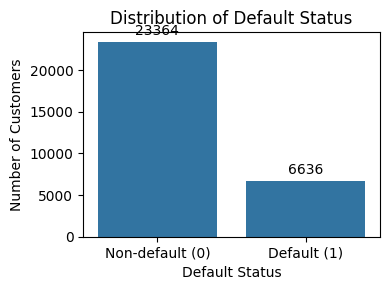

In [11]:
# plotting the target variable summary
# Plot target distribution
plt.figure(figsize=(4, 3))

ax = sns.countplot(
    data=df,
    x="target",
    order=[0, 1]
)

plt.title("Distribution of Default Status")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-default (0)", "Default (1)"]
)

# Add frequency labels
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

In [12]:
## 3.4 Ranges and validity check
# The observed ranges and unique values of key variables are examined against their expected coding and measurement scales.
# Particular attention is given to demographic variables and repayment-status variables,
# which use numerical codes to represent categorical or ordinal information.

print("Age range:", df["AGE"].min(), "to", df["AGE"].max())
print("Credit limit range:", df["LIMIT_BAL"].min(), "to", df["LIMIT_BAL"].max())

print("\nSEX codes {1=Male,2=Female}:")
print(sorted(df["SEX"].unique()))

print("\nEDUCATION codes:")
print(sorted(df["EDUCATION"].unique()))

print("\nMARRIAGE codes:")
print(sorted(df["MARRIAGE"].unique()))

print("\nRepayment status codes:")
for col in ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
    print(col, sorted(df[col].unique()))


Age range: 21 to 79
Credit limit range: 10000 to 1000000

SEX codes {1=Male,2=Female}:
[np.int64(1), np.int64(2)]

EDUCATION codes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

MARRIAGE codes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Repayment status codes:
PAY_1 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3),

###  Summary of Data Quality Assessment

The dataset contains 30,000 observations and 24 variables. No missing values were identified across the variables, so no missing-data treatment is required at this stage. A total of 35 duplicate observations were detected and will be investigated further before any observations are removed.

The response variable, `target`, is binary, with 23,364 non-default observations (77.88%) and 6,636 default observations (22.12%). Thus, default represents the minority outcome in the dataset. This class distribution is relevant for subsequent model evaluation, since overall classification accuracy alone may not adequately describe performance for the minority default class.

The demographic and repayment-status variables are represented using numerical codes. These codes will be treated according to their statistical meaning rather than automatically being interpreted as continuous measurements.

# 4 Exploratory Data Analysis

In [13]:
## 4.1 Univariate Analysis of Demographic and Financial Variables

# The demographic variables SEX, EDUCATION, and MARRIAGE are analysed as categorical variables,
# while LIMIT_BAL is treated as a quantitative financial variable.
# Examining these distributions provides an initial understanding of the composition of the customer population
# and identifies any pronounced concentration, skewness, or unusual patterns that may be relevant to subsequent
# credit-risk modelling.
# For the categorical variables, frequency and percentage distributions are reported.
# For the credit-limit variable, numerical summary statistics and a graphical distribution are examined.

# ---------------------------------------------------------
# 1. Categorical demographic variables
# ---------------------------------------------------------

categorical_vars = ["SEX", "EDUCATION", "MARRIAGE"]

for var in categorical_vars:
    print(f"\nDistribution of {var}")

    summary = pd.DataFrame({
        "Frequency": df[var].value_counts(dropna=False).sort_index(),
        "Percentage": (
            df[var].value_counts(normalize=True, dropna=False).sort_index() * 100
        )
    })

    display(summary.round(2))


Distribution of SEX


,Frequency,Percentage
SEX,,
1,11888,39.63
2,18112,60.37



Distribution of EDUCATION


,Frequency,Percentage
EDUCATION,,
0,14,0.05
1,10585,35.28
2,14030,46.77
3,4917,16.39
4,123,0.41
5,280,0.93
6,51,0.17



Distribution of MARRIAGE


,Frequency,Percentage
MARRIAGE,,
0,54,0.18
1,13659,45.53
2,15964,53.21
3,323,1.08


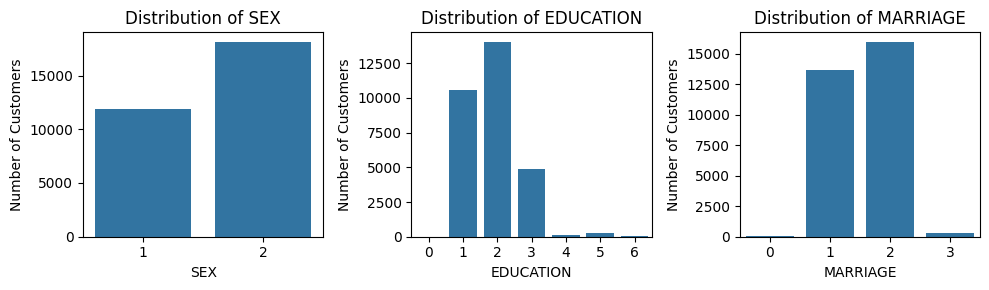

In [14]:
# Visualisation of demographic variables

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, var in zip(axes, categorical_vars):
    sns.countplot(
        data=df,
        x=var,
        order=sorted(df[var].dropna().unique()),
        ax=ax
    )

    ax.set_title(f"Distribution of {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [15]:
# ---------------------------------------------------------
# 2. Quantitative financial variable: LIMIT_BAL
# ---------------------------------------------------------

print("Descriptive Statistics for LIMIT_BAL:")
display(df["LIMIT_BAL"].describe().to_frame().T)

# Additional measures useful for assessing skewness
limit_bal_summary = pd.DataFrame({
    "Median": [df["LIMIT_BAL"].median()],
    "Standard Deviation": [df["LIMIT_BAL"].std()],
    "Minimum": [df["LIMIT_BAL"].min()],
    "Maximum": [df["LIMIT_BAL"].max()],
    "Skewness": [df["LIMIT_BAL"].skew()]
})

display(limit_bal_summary.round(2))

Descriptive Statistics for LIMIT_BAL:


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.0,140000.0,240000.0,1000000.0


,Median,Standard Deviation,Minimum,Maximum,Skewness
0,140000.0,129747.66,10000,1000000,0.99


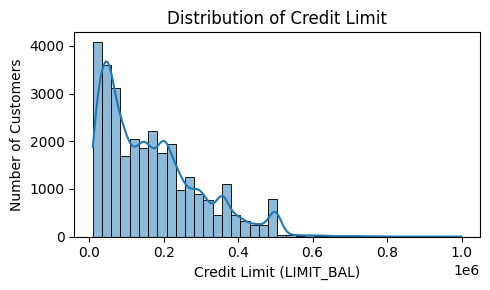

In [16]:
# Distribution of credit limit

plt.figure(figsize=(5, 3))

sns.histplot(
    data=df,
    x="LIMIT_BAL",
    bins=40,
    kde=True
)

plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit (LIMIT_BAL)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


The LIMIT_BAL distribution is positively (right) skewed, with most customers having relatively low to moderate credit limits and fewer customers having higher credit limits. The distribution extends to approximately NTD 1,000,000.

Several concentrations are visible at particular credit-limit values, reflecting the discrete levels at which credit limits are assigned. Overall, LIMIT_BAL shows substantial variability and right skewness, which will be considered when examining its relationship with default in subsequent analyses.


In [17]:
## 4.2 Analysis of Repayment Status Variables

# The variables `PAY_1`–`PAY_6` describe customers' repayment status across successive months.
# Although numerically coded, these variables represent **ordinal categories**
# and are therefore analysed according to their repayment-status levels rather than as continuous measurements.
# Their frequency distributions are examined to identify common repayment patterns and the prevalence of delayed payments.

pay_vars = ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Frequency and percentage distributions
for var in pay_vars:
    print(f"\nDistribution of {var}")

    summary = pd.DataFrame({
        "Frequency": df[var].value_counts().sort_index(),
        "Percentage": (
            df[var].value_counts(normalize=True).sort_index() * 100
        )
    })

    display(summary.round(2))


Distribution of PAY_1


,Frequency,Percentage
PAY_1,,
-2,2759,9.20
-1,5686,18.95
0,14737,49.12
1,3688,12.29
2,2667,8.89
3,322,1.07
4,76,0.25
5,26,0.09
6,11,0.04



Distribution of PAY_2


,Frequency,Percentage
PAY_2,,
-2,3782,12.61
-1,6050,20.17
0,15730,52.43
1,28,0.09
2,3927,13.09
3,326,1.09
4,99,0.33
5,25,0.08
6,12,0.04



Distribution of PAY_3


...

,Frequency,Percentage
PAY_4,,
-2,4348,14.49
-1,5687,18.96
0,16455,54.85
1,2,0.01
2,3159,10.53
3,180,0.60
4,69,0.23
5,35,0.12
6,5,0.02



Distribution of PAY_5


,Frequency,Percentage
PAY_5,,
-2,4546,15.15
-1,5539,18.46
0,16947,56.49
2,2626,8.75
3,178,0.59
4,84,0.28
5,17,0.06
6,4,0.01
7,58,0.19



Distribution of PAY_6


,Frequency,Percentage
PAY_6,,
-2,4895,16.32
-1,5740,19.13
0,16286,54.29
2,2766,9.22
3,184,0.61
4,49,0.16
5,13,0.04
6,19,0.06
7,46,0.15


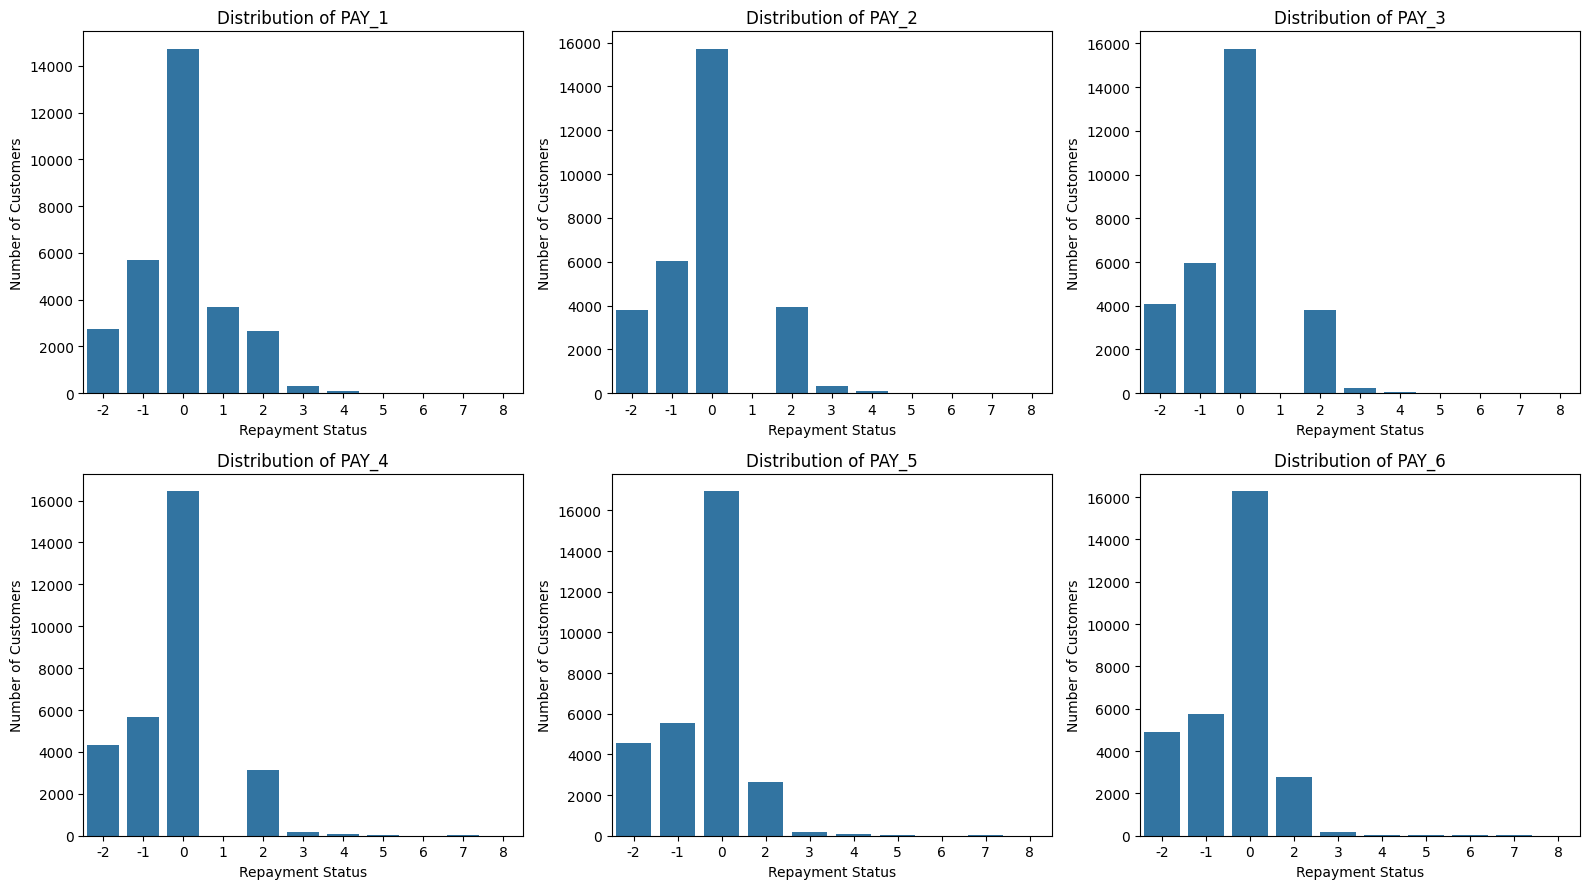

In [18]:
# Plot repayment-status distributions

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, var in zip(axes, pay_vars):
    sns.countplot(
        data=df,
        x=var,
        order=sorted(df[var].dropna().unique()),
        ax=ax
    )

    ax.set_title(f"Distribution of {var}")
    ax.set_xlabel("Repayment Status")
    ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()



The repayment-status distributions are concentrated mainly in categories `-2`, `-1`, and `0`, while higher positive categories occur less frequently. `PAY_1` shows a greater presence of positive repayment delays than the earlier repayment-status variables, indicating more recent delinquency among a subset of customers. Overall, the distributions suggest that most customers have limited repayment delays, while a smaller group exhibits more severe or recent delinquency.

In [19]:
## 4.3 Analysis of Bill Amount and Payment Amount Variables

# The bill statement and previous payment variables represent customers' financial obligations and
# payment behaviour across six monthly periods.
# Their distributions are examined using summary statistics and boxplots to assess variability, skewness, and potential extreme values.

bill_vars = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

pay_amt_vars = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

amount_vars = bill_vars + pay_amt_vars

# Descriptive statistics
amount_summary = df[amount_vars].describe().T

display(amount_summary.round(2))



,count,mean,std,min,25%,50%,75%,max
0,,,,,,,,
BILL_AMT1,30000.0,51223.33,73635.86,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.08,71173.77,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.15,69349.39,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.95,64332.86,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.40,60797.16,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.76,59554.11,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.58,16563.28,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.16,23040.87,0.0,833.00,2009.0,5000.00,1684259.0
PAY_AMT3,30000.0,5225.68,17606.96,0.0,390.00,1800.0,4505.00,896040.0


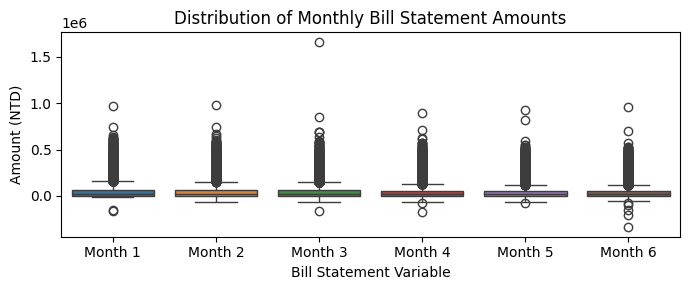

In [20]:
# Boxplots for bill statement amounts

plt.figure(figsize=(7, 3))

sns.boxplot(data=df[bill_vars])

plt.title("Distribution of Monthly Bill Statement Amounts")
plt.xlabel("Bill Statement Variable")
plt.ylabel("Amount (NTD)")

plt.xticks(
    ticks=range(6),
    labels=["Month 1", "Month 2", "Month 3",
            "Month 4", "Month 5", "Month 6"]
)

plt.tight_layout()
plt.show()

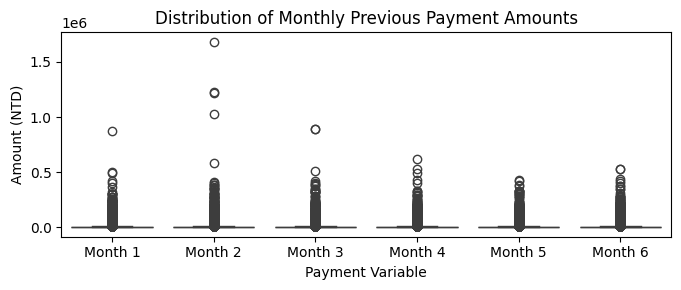

In [21]:
# Boxplots for previous payment amounts

plt.figure(figsize=(7,3))

sns.boxplot(data=df[pay_amt_vars])

plt.title("Distribution of Monthly Previous Payment Amounts")
plt.xlabel("Payment Variable")
plt.ylabel("Amount (NTD)")

plt.xticks(
    ticks=range(6),
    labels=["Month 1", "Month 2", "Month 3",
            "Month 4", "Month 5", "Month 6"]
)

plt.tight_layout()
plt.show()




The monthly bill amounts are positively skewed, with most observations concentrated at relatively lower values and fewer customers having substantially higher bill amounts. Numerous extreme values are present across the six months, indicating considerable variation in customers' outstanding bill amounts.



The previous payment amounts are strongly right-skewed, with most customers making relatively small payments and a smaller number making substantially larger payments. Numerous high-value observations are present across the six months, indicating considerable variation in customers' payment behaviour.

/tmp/ipykernel_1960/4189605209.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Non-default (0)", "Default (1)"])
/tmp/ipykernel_1960/4189605209.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Non-default (0)", "Default (1)"])


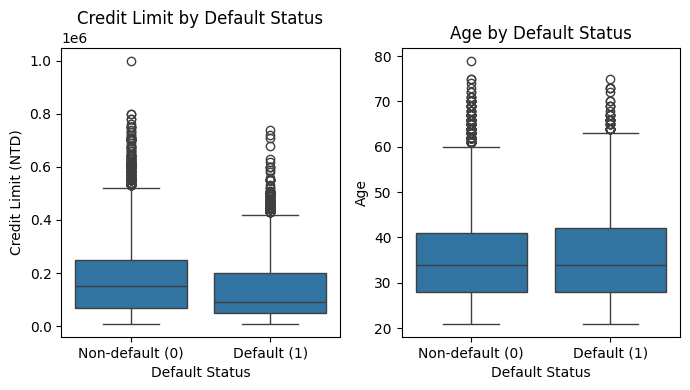

In [22]:
## 4.4 Bivariate Analysis: Key Predictors and Default

# Bivariate analysis examines selected predictors in relation to default status.
# This provides an initial indication of variables that may be associated with default risk
# before fitting the multivariable logistic-regression model.

fig, axes = plt.subplots(1, 2, figsize=(7,4))

# Credit limit by default status
sns.boxplot(
    data=df,
    x="target",
    y="LIMIT_BAL",
    ax=axes[0]
)

axes[0].set_title("Credit Limit by Default Status")
axes[0].set_xlabel("Default Status")
axes[0].set_ylabel("Credit Limit (NTD)")
axes[0].set_xticklabels(["Non-default (0)", "Default (1)"])

# Age by default status
sns.boxplot(
    data=df,
    x="target",
    y="AGE",
    ax=axes[1]
)

axes[1].set_title("Age by Default Status")
axes[1].set_xlabel("Default Status")
axes[1].set_ylabel("Age")
axes[1].set_xticklabels(["Non-default (0)", "Default (1)"])

plt.tight_layout()
plt.show()

In [23]:
# Default rate by PAY_1 repayment status

pay1_rates = (
    df.groupby("PAY_1")["target"]
      .mean()
      .mul(100)
      .reset_index(name="Default Rate")
)

display(pay1_rates.round(2))

,PAY_1,Default Rate
0,-2,13.23
1,-1,16.78
2,0,12.81
3,1,33.95
4,2,69.14
5,3,75.78
6,4,68.42
7,5,50.00
8,6,54.55
9,7,77.78


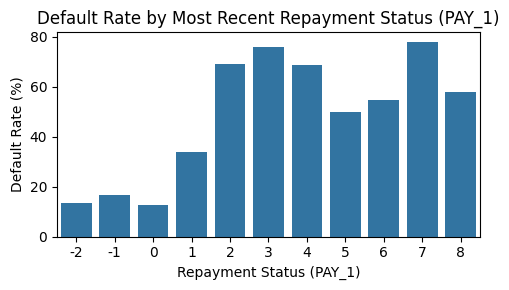

In [24]:
plt.figure(figsize=(5, 3))

sns.barplot(
    data=pay1_rates,
    x="PAY_1",
    y="Default Rate"
)

plt.title("Default Rate by Most Recent Repayment Status (PAY_1)")
plt.xlabel("Repayment Status (PAY_1)")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

### Interpretation

Defaulting customers had a lower median credit limit than non-defaulting customers, with median limits of NTD 90,000 and NTD 150,000, respectively. The mean credit limit was also lower among defaulters (NTD 130,109.66) compared with non-defaulters (NTD 178,099.73).

The repayment-status analysis also indicates differences in default rates across `PAY_1` categories, with more severe recent repayment delays generally associated with higher default rates. These findings suggest that credit limit and recent repayment behaviour contain useful information for distinguishing default and non-default customers.

However, these are bivariate relationships and do not account for the effects of other predictors. Their independent effects will therefore be assessed using logistic regression in the subsequent modelling stage.


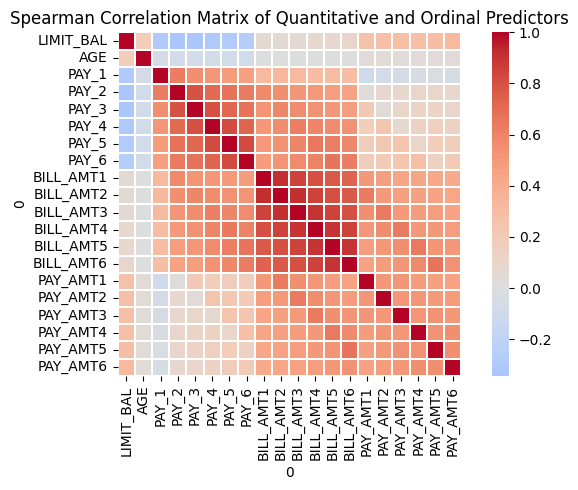

In [25]:
## 4.5 Correlation Analysis

# Correlation analysis is used to examine relationships among quantitative and ordinal predictor variables.
# Identifying highly correlated predictors is important because strong correlations may indicate redundancy and
# potential multicollinearity in the subsequent logistic-regression model.
correlation_vars = [
    "LIMIT_BAL",
    "AGE",
    "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]
corr_matrix = df[correlation_vars].corr(method="spearman")

plt.figure(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3
)
plt.title("Spearman Correlation Matrix of Quantitative and Ordinal Predictors")
plt.tight_layout()
plt.show()

The correlation matrix shows that several predictors are correlated, particularly variables representing bill amounts and payment amounts across successive months. This is expected because these variables measure related aspects of customers' financial behaviour over time.

The repayment-status variables also show relationships across months, reflecting persistence in customers' repayment behaviour. These correlations indicate some degree of redundancy among predictors and therefore highlight the importance of assessing multicollinearity during logistic-regression modelling.



# Key Findings from EDA

The exploratory analysis identified several characteristics relevant to credit-risk modelling. `LIMIT_BAL`, bill amounts, and payment amounts showed positively skewed distributions with substantial variability and extreme observations. The repayment-status variables were concentrated mainly in lower-delay categories, while recent repayment behaviour showed differences in default rates across categories.

Defaulters had lower average and median credit limits than non-defaulters, indicating an association between credit limit and default status. The correlation analysis also identified relationships among predictors that may introduce redundancy and potential multicollinearity.

These findings provide the basis for the subsequent logistic-regression modelling, where the independent contribution of the predictors to default risk will be assessed while considering model specification and multicollinearity.

# 5. Logistic Regression Modelling

Logistic regression is used to model the probability that a customer defaults on their credit-card payment. Since the target variable is binary, with 0 representing non-default and 1 representing default, logistic regression provides an appropriate statistical framework for estimating default probabilities and assessing the contribution of individual predictors.



In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
y=df["target"]
X=df.drop(columns=["target"])
# Encode categorical variables
categorical_vars = ["SEX", "EDUCATION", "MARRIAGE"]

X = pd.get_dummies(
    X,
    columns=categorical_vars,
    drop_first=True,
    dtype=int
)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=52)
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
LR=LogisticRegression()
df_fit=LR.fit(X_train_scaled,y_train)
print("\ndata fitted succesfully")



data fitted succesfully


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predictions on the test set
y_pred = LR.predict(X_test_scaled)

# Predicted probabilities of default
y_prob = LR.predict_proba(X_test_scaled)[:, 1]

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance on Test Set")
print("-" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(
    cm,
    index=["Actual Non-default", "Actual Default"],
    columns=["Predicted Non-default", "Predicted Default"]
))

Model Performance on Test Set
-----------------------------------
Accuracy : 0.8122
Precision: 0.7171
Recall   : 0.2468
F1-score : 0.3672

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4675
           1       0.72      0.25      0.37      1325

    accuracy                           0.81      6000
   macro avg       0.77      0.61      0.63      6000
weighted avg       0.80      0.81      0.77      6000

Confusion Matrix:


,Predicted Non-default,Predicted Default
Actual Non-default,4546,129
Actual Default,998,327


### Interpretation

The logistic regression model achieved an accuracy of 81.22% on the test set. For the default class, the model achieved a precision of 71.71%, indicating that most customers predicted as defaulters were actually defaulters. However, recall was 24.68%, meaning that the model identified approximately one-quarter of the actual defaulters.

The confusion matrix shows that 327 of the 1,325 actual defaulters were correctly identified, while 998 were classified as non-default. Therefore, although the model provides useful discrimination between the two classes, its ability to identify actual defaulters remains limited at the default classification threshold of 0.50.

###  Cross-Validation of Logistic Regression

To assess the stability of the logistic regression model's predictive performance, 5-fold stratified cross-validation is performed on the training dataset. Stratification ensures that the proportion of default and non-default observations is approximately preserved across the five folds.

The training data are divided into five folds. In each iteration, four folds are used for model fitting and the remaining fold is used for validation. This process is repeated five times so that each observation is used once for validation.

The model is evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. The mean cross-validation score provides an estimate of the model's average predictive performance, while the standard deviation measures the variation in performance across the folds.

Standardization is performed within the cross-validation pipeline to prevent information from a validation fold from influencing the scaling parameters used during model fitting.


In [42]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# Define 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=52
)

# Logistic regression pipeline
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

# Cross-validation
cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=False
)

# Summarize cross-validation results
cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Mean CV Score": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Standard Deviation": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

cv_summary["Mean CV Score"] = cv_summary["Mean CV Score"].round(4)


display(cv_summary)

,Metric,Mean CV Score,Standard Deviation
0,Accuracy,0.8111,0.004383
1,Precision,0.7157,0.022173
2,Recall,0.2425,0.016579
3,F1-score,0.3621,0.020996
4,ROC-AUC,0.7249,0.003404


The 5-fold stratified cross-validation results indicate that the logistic regression model achieves a mean accuracy of 0.8111 and a mean ROC-AUC of 0.7249 across the five validation folds. The relatively small standard deviation of ROC-AUC (0.0034) indicates that the model's discriminatory performance is reasonably stable across different validation samples.

The mean precision is 0.7157, whereas the mean recall is 0.2425. This indicates that although a substantial proportion of observations predicted as default are actually defaults, the model identifies only a relatively small proportion of all actual default cases at the default classification threshold. The mean F1-score of 0.3621 reflects this imbalance between precision and recall.

Overall, the cross-validation results provide evidence that the logistic regression model has reasonably stable predictive performance, while also highlighting the difficulty of identifying the minority default class. Further evaluation using ROC-AUC, precision-recall analysis, threshold analysis, and calibration will therefore be important rather than relying on accuracy alone.


###  ROC Curve and ROC-AUC

The Receiver Operating Characteristic (ROC) curve is used to evaluate the discriminatory ability of the logistic regression model across different classification thresholds. The ROC curve plots the True Positive Rate (Sensitivity) against the False Positive Rate (1 − Specificity).

The Area Under the ROC Curve (ROC-AUC) provides a threshold-independent measure of discrimination. It can be interpreted as the probability that the model assigns a higher predicted probability of default to a randomly selected defaulting customer than to a randomly selected non-defaulting customer.

The ROC-AUC is calculated using the predicted probabilities obtained from the test dataset. Since the test set was not used during model fitting, this provides an out-of-sample assessment of the model's discriminatory performance.

ROC-AUC: 0.7210


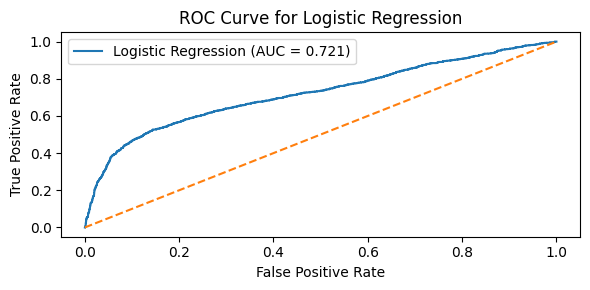

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc_score:.4f}")

# Plot ROC curve
plt.figure(figsize=(6,3))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretation

The logistic regression model achieves a ROC-AUC of **0.721** on the held-out test dataset. This indicates that the model has discriminatory ability above random classification, represented by an AUC of 0.5.

The test-set ROC-AUC is also close to the mean 5-fold cross-validation ROC-AUC of **0.7249**, suggesting that the model's discriminatory performance is reasonably consistent between cross-validation and the independent test set.

However, ROC-AUC evaluates ranking ability across all possible classification thresholds and does not by itself determine the most appropriate threshold for identifying default. Therefore, precision-recall analysis, threshold analysis, and calibration will be considered in subsequent sections.

In [30]:
# Extract logistic regression coefficients
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": LR.coef_[0]
})

# Calculate odds ratios
coefficients["Odds Ratio"] = np.exp(coefficients["Coefficient"])

# Sort by coefficient
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficients.round(4))

,Variable,Coefficient,Odds Ratio
2,PAY_1,0.6508,1.9171
27,MARRIAGE_1,0.5300,1.6990
28,MARRIAGE_2,0.4476,1.5645
9,BILL_AMT2,0.2318,1.2609
21,EDUCATION_1,0.2251,1.2524
22,EDUCATION_2,0.1947,1.2150
23,EDUCATION_3,0.1383,1.1483
3,PAY_2,0.1034,1.1089
29,MARRIAGE_3,0.0991,1.1042
10,BILL_AMT3,0.0915,1.0958


### Interpretation of Logistic Regression Coefficients

The estimated coefficients indicate the direction of association between the predictors and the probability of default. Positive coefficients are associated with higher odds of default, while negative coefficients are associated with lower odds of default.

`PAY_1` has the largest positive coefficient among the repayment-status variables, with an odds ratio of 1.917. This indicates that higher recent repayment-status values are associated with higher odds of default. In contrast, `PAY_AMT1` and `PAY_AMT2` have odds ratios below 1, indicating an inverse association between previous payment amounts and default odds.

`LIMIT_BAL` has an odds ratio of 0.913, suggesting that higher credit limits are associated with lower odds of default. `BILL_AMT1` also has an odds ratio below 1, while `BILL_AMT2` and `BILL_AMT3` have positive coefficients.

The categorical variables are interpreted relative to their omitted reference categories created through dummy encoding. Overall, the coefficients indicate that repayment behaviour, credit limit, and payment and bill amounts contain information about default risk.

Because the predictors were standardised before estimation, the odds ratios for continuous variables correspond to a one-standard-deviation increase in the predictor. The coefficients represent associations within the fitted multivariable model and should not be interpreted as causal effects.

### Multicollinearity Assessment

Multicollinearity occurs when predictors contain substantial overlapping information. This can make regression coefficients unstable and difficult to interpret. Variance Inflation Factor (VIF) is therefore used to assess the degree of multicollinearity among the predictors included in the logistic-regression model.

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for the scaled training predictors
vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X_train_scaled, i)
        for i in range(X_train_scaled.shape[1])
    ]
})

vif = vif.sort_values("VIF", ascending=False)

display(vif.round(2))

,Variable,VIF
22,EDUCATION_2,598.70
21,EDUCATION_1,549.60
23,EDUCATION_3,331.90
28,MARRIAGE_2,134.22
27,MARRIAGE_1,133.53
9,BILL_AMT2,24.67
12,BILL_AMT5,24.01
25,EDUCATION_5,24.00
10,BILL_AMT3,23.19
11,BILL_AMT4,21.67


In [32]:
# VIF for the main numerical and repayment-status predictors
import statsmodels.api as sm
vif_vars = [
    "LIMIT_BAL", "AGE",
    "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

X_vif = sm.add_constant(X_train[vif_vars])

vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif = vif[vif["Variable"] != "const"]
vif = vif.sort_values("VIF", ascending=False)

display(vif.round(2))

,Variable,VIF
10,BILL_AMT2,24.67
13,BILL_AMT5,23.99
11,BILL_AMT3,23.17
12,BILL_AMT4,21.65
14,BILL_AMT6,14.22
9,BILL_AMT1,13.49
7,PAY_5,4.80
6,PAY_4,4.33
5,PAY_3,3.70
8,PAY_6,3.30


### Interpretation

The VIF results indicate that the highest multicollinearity occurs among the monthly bill amount variables (`BILL_AMT1`–`BILL_AMT6`), with VIF values ranging from 13.49 to 24.67. This is expected because these variables measure related bill amounts across consecutive months.

The repayment-status variables have VIF values between 1.93 and 4.80, indicating some correlation across months but no severe multicollinearity based on the commonly used threshold of 5. The payment amount variables, `LIMIT_BAL`, and `AGE` have relatively low VIF values.

Overall, the results indicate that multicollinearity is mainly concentrated among the monthly bill amount variables. This should be considered when interpreting individual regression coefficients, but the current model specification is retained for the baseline analysis.

# 6. Credit Scorecard Development

The logistic regression model provides estimated probabilities of default for individual customers. To make these estimates more suitable for credit-risk assessment, they are transformed into a numerical credit score.

The score is constructed so that higher scores represent lower estimated default risk, while lower scores represent higher estimated default risk. The resulting scores are then examined across different score ranges to assess whether they maintain a consistent relationship with observed default rates.

In [33]:
## 6.1 Create a score from predicted probability of default

scorecard_results = pd.DataFrame({
    "Actual": y_test.values,
    "Probability_of_Default": y_prob
})

# Convert probability of default to a raw score
scorecard_results["Raw_Score"] = (
    600 - 100 * np.log(
        scorecard_results["Probability_of_Default"] /
        (1 - scorecard_results["Probability_of_Default"])
    )
)

scorecard_results["Raw_Score"] = (
    scorecard_results["Raw_Score"].round(0)
)

display(scorecard_results.head(10))

,Actual,Probability_of_Default,Raw_Score
0,0,0.156699,768.0
1,0,0.039648,919.0
2,0,0.186936,747.0
3,1,0.206829,734.0
4,0,0.055570,883.0
5,0,0.157851,767.0
6,0,0.103386,816.0
7,0,0.044906,906.0
8,0,0.356045,659.0
9,0,0.148347,775.0


In [34]:
# checking raw_score summary
scorecard_results["Raw_Score"].describe()

,Raw_Score
count,6000.000000
mean,746.212833
std,101.000426
min,114.000000
25%,703.000000
50%,741.000000
75%,800.000000
max,2570.000000


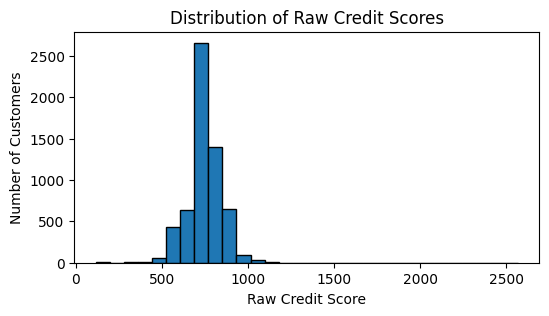

In [35]:
## 6.2 Score Distribution

# The raw credit scores are examined to understand their range and distribution before creating score bands.
# This step helps identify the central range of scores and provides a basis for defining meaningful score intervals
# for subsequent scorecard validation.

# Summary statistics for the raw credit scores
scorecard_results["Raw_Score"].describe()
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))

plt.hist(
    scorecard_results["Raw_Score"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Raw Credit Score")
plt.ylabel("Number of Customers")
plt.title("Distribution of Raw Credit Scores")

plt.show()

### Interpretation

The raw credit scores have a mean of 746.21 and a median of 741, with a standard deviation of 101.00. The middle 50% of customers have scores between 703 and 800. Although the overall score range is wide, from 114 to 2,570, the histogram shows that most observations are concentrated within the central range.

The relatively high maximum score is associated with customers having very low predicted probabilities of default. Overall, the score distribution provides sufficient variation for grouping customers into score bands and examining whether lower scores are associated with higher observed default rates.

In [36]:
# Create credit score bands

score_bins = [0, 500, 600, 700, 800, 900, 1000, np.inf]
score_labels = [
    "<500",
    "500-599",
    "600-699",
    "700-799",
    "800-899",
    "900-999",
    "1000+"
]

scorecard_results["Score_Band"] = pd.cut(
    scorecard_results["Raw_Score"],
    bins=score_bins,
    labels=score_labels,
    right=False
)

display(
    scorecard_results["Score_Band"]
    .value_counts()
    .sort_index()
)

,count
Score_Band,
<500,54
500-599,401
600-699,957
700-799,3076
800-899,1228
900-999,232
1000+,52


In [37]:
## Default Rate by Score Band

# The observed default rate is calculated within each score band to assess whether the credit score maintains
# a consistent relationship with actual default outcomes.
# A well-behaved scorecard should generally show higher observed default rates among customers with lower scores
# and lower default rates among customers with higher scores.

# Calculate observed default rate and customer count for each score band
score_band_summary = (
    scorecard_results
    .groupby("Score_Band", observed=False)
    .agg(
        Customers=("Actual", "count"),
        Defaults=("Actual", "sum"),
        Default_Rate=("Actual", "mean")
    )
    .reset_index()
)

score_band_summary["Default_Rate_Percent"] = (
    score_band_summary["Default_Rate"] * 100
)

display(
    score_band_summary.round({
        "Default_Rate": 4,
        "Default_Rate_Percent": 2
    })
)

,Score_Band,Customers,Defaults,Default_Rate,Default_Rate_Percent
0,<500,54,42,0.7778,77.78
1,500-599,401,284,0.7082,70.82
2,600-699,957,375,0.3918,39.18
3,700-799,3076,451,0.1466,14.66
4,800-899,1228,147,0.1197,11.97
5,900-999,232,21,0.0905,9.05
6,1000+,52,5,0.0962,9.62


### Interpretation

The observed default rates show a strong relationship with the credit-score bands. Customers in the lowest score band (`<500`) had an observed default rate of 77.78%, compared with 70.82% for the `500–599` band and 39.18% for the `600–699` band.

The default rate declined substantially to 14.66% for customers with scores between 700 and 799 and remained below 12% for the higher score bands. The `900–999` band had a default rate of 9.05%, while the `1000+` band had a slightly higher rate of 9.62%. However, the latter band contains only 52 customers and 5 defaults, so this small difference should be interpreted cautiously.

Overall, the score bands demonstrate that lower credit scores are generally associated with higher observed default rates, supporting the risk-ordering property of the proposed scorecard.

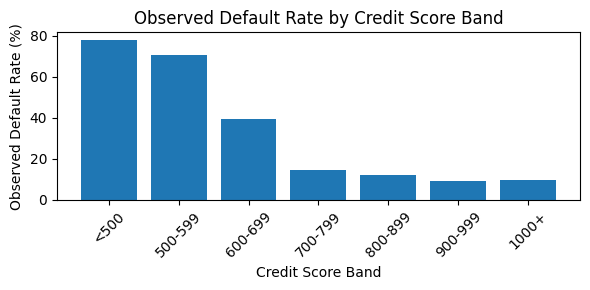

In [38]:
# Plot observed default rate by score band

plt.figure(figsize=(6,3))

plt.bar(
    score_band_summary["Score_Band"].astype(str),
    score_band_summary["Default_Rate_Percent"]
)

plt.xlabel("Credit Score Band")
plt.ylabel("Observed Default Rate (%)")
plt.title("Observed Default Rate by Credit Score Band")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Scorecard Validation

The scorecard is validated by examining whether observed default rates generally decrease as credit scores increase. This assesses the risk-ordering property of the scorecard, whereby customers assigned higher scores should generally exhibit lower observed default risk.

In [39]:
from scipy.stats import spearmanr

score_correlation, p_value = spearmanr(
    scorecard_results["Raw_Score"],
    scorecard_results["Actual"]
)

print(f"Spearman correlation: {score_correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Spearman correlation: -0.3176
P-value: 0.0000


### Interpretation

The Spearman correlation between the raw credit score and the actual default outcome was -0.3176, with a p-value below 0.001. The negative correlation indicates that higher credit scores are associated with lower default outcomes.

This finding is consistent with the score-band analysis, where lower score bands generally showed higher observed default rates. The statistically significant association provides additional evidence that the proposed scorecard preserves the expected risk-ordering relationship between credit score and default.

### 6.3 Final Interpretation of the Scorecard

The developed scorecard converts the logistic-regression predicted probability of default into a numerical credit score, with higher scores representing lower estimated default risk. The score distribution showed substantial variation, with a median score of 741 and most customers concentrated between scores of 703 and 800.

The score-band analysis demonstrated a clear risk-ordering pattern. Customers in the lower score bands generally had substantially higher observed default rates, while higher score bands had lower default rates. For example, the observed default rate decreased from 77.78% in the `<500` score band to 14.66% in the `700–799` band.

The Spearman correlation between credit score and observed default status was -0.3176 (p < 0.001), providing statistical evidence of a negative monotonic association between score and default. This is consistent with the expected interpretation of the scorecard, where increasing scores correspond to decreasing default risk.

The slight increase in default rate in the `1000+` band should be interpreted cautiously because this band contains only 52 customers and 5 observed defaults. Overall, the scorecard demonstrates the expected risk-ordering relationship, although the score scale is project-specific and is not intended to represent an industry-standard credit score.

The scorecard should therefore be interpreted as a transformation of the fitted logistic-regression model for credit-risk segmentation rather than as a calibrated industry credit-rating system.

# 7. Discussion and Limitations

The analysis developed a logistic-regression model for predicting credit-card default and transformed the resulting predicted probabilities into a numerical credit score. The model demonstrated moderate discriminatory ability, with a test ROC-AUC of 0.721, while the scorecard showed a clear overall relationship between higher scores and lower observed default rates.

The exploratory and modelling results highlighted the importance of recent repayment behaviour, credit limits, and payment and bill amounts in distinguishing default and non-default customers. Multicollinearity was mainly observed among the monthly bill amount variables, reflecting the related nature of these measurements across time.

Several limitations should be considered when interpreting the results. The scorecard uses a project-specific scoring scale rather than an industry-standard credit-score system. In addition, the model was developed using a single train-test split, so performance estimates may vary under different samples or resampling procedures. The relatively low recall for the default class also indicates that the model does not identify all customers who eventually default at the 0.50 classification threshold.

Finally, the scorecard represents statistical associations identified in the available dataset and should not be interpreted as establishing causal relationships. Further validation using independent or external datasets would be required before considering practical deployment.

# 8. Conclusion

This project developed a logistic-regression-based credit-risk model and scorecard using the UCI Default of Credit Card Clients dataset. The analysis began with data-quality assessment and exploratory analysis to understand the distribution of customer characteristics, repayment behaviour, bill amounts, and payment amounts.

The logistic regression model was evaluated on an unseen test set and achieved an accuracy of 81.22% and a ROC-AUC of 0.721, indicating moderate discriminatory ability. The model identified differences in default risk associated with repayment behaviour, credit limits, and payment and bill amounts. Multicollinearity was found mainly among the monthly bill amount variables, which was considered when interpreting the regression coefficients.

The predicted probabilities of default were subsequently transformed into a numerical credit score using a log-odds-based scoring function. The resulting scorecard demonstrated the expected risk-ordering relationship, with lower score bands generally exhibiting higher observed default rates. The Spearman correlation between the credit score and observed default outcome was -0.3176 (p < 0.001), providing further evidence of the negative relationship between score and default.

Overall, the analysis demonstrates how logistic regression can be used not only to estimate credit-default probabilities but also to construct an interpretable numerical score for credit-risk segmentation. The developed scorecard is a project-specific statistical model and would require further external validation and calibration before being considered for operational credit-risk decision-making.